# American Put Pricing under the LLH Model

We price American put options via the Longstaff-Schwartz (LSM) algorithm under
the LLH (Lin-Lin-He, 2024) stochastic volatility model. Three estimators are
compared:

1. **Plain LSM** — standard least-squares Monte Carlo.
2. **LSM + CV (BS)** — Rasmussen control variate using the Black-Scholes European put.
3. **LSM + CV (LLH)** — Rasmussen control variate using the exact LLH European put.

Results are organized by parameter set (Tables 1 and 2 from Lin, Lin & He),
horizon (1-month vs 1-year), and moneyness (deep ITM to deep OTM for puts).

## Contents

1. [LLH Model](#llh-model)
2. [Setup and Parameters](#setup)
3. [Price Path Simulation](#simulate)
4. [American Put Pricing: 1-Month Horizon](#1month)
   - 4.1 Table 1 Parameters
   - 4.2 Table 2 Parameters
5. [American Put Pricing: 1-Year Horizon](#1year)
   - 5.1 Table 1 Parameters
   - 5.2 Table 2 Parameters
   - 5.3 Black-Scholes Limit
6. [Early Exercise Premium](#eep)
7. [Variance Reduction Analysis](#vr-analysis)
8. [Timing Comparison](#timing)

<a id="llh-model"></a>
## 1. LLH Model

\begin{align}
    \frac{dS_t}{S_t} &= rdt + \sigma_tdW^1_t\\
    d\sigma_t &= \kappa(\theta_t-\sigma_t)dt + \nu dW^2_t\\
    d\theta_t &= \lambda dt + \eta dW_t\\
    \text{ }\notag\\
    \text{cov}&(W^1_t,W^2_t)=\rho t \notag
\end{align}

- $W^1_t,\,W^2_t$ are correlated Brownian motions, $W_t$ independent Brownian motion.
- $\Theta = (\kappa,\,\nu,\,\lambda,\,\eta,\, \rho)$ are the model parameters.

<a id="setup"></a>
## 2. Setup and Parameters

In [1]:
import sys, time
sys.path.insert(0, '../src')

import priceModels as pm
import amerPrice as ap
from reporting import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Table 1 parameters (Lin, Lin & He 2024)
model_t1 = pm.ImprovedSteinStein(
    r=0.01, rho=-0.2, kappa=5, nu=0.2,
    sigma0=0.15, theta0=0.18, lam=0.9, eta=0.01, seed=42
)

# Table 2 parameters (Lin, Lin & He 2024)
model_t2 = pm.ImprovedSteinStein(
    r=0.01, rho=0.1691, kappa=4.9394, nu=0.3943,
    sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112, seed=42
)

In [3]:
# Moneyness grid for American puts (K fixed, vary S0)
K = 100.0
S0_GRID = [85.0, 90.0, 100.0, 110.0, 115.0]
MONEYNESS_LABELS = ['Deep ITM', 'ITM', 'ATM', 'OTM', 'Deep OTM']

# Horizon definitions
HORIZONS = {
    '1-month': {'T': 1/12, 'n_steps_mc': 22},
    '1-year':  {'T': 1.0,  'n_steps_mc': 52},
}

# Path counts
N_PATHS       = 10_000   # plain LSM and CV-BS 
N_PATHS_LLH   = 10_000    # CV-LLH (expensive: ODE solve per exercise date)

# LLH quadrature parameters (controls accuracy of ODE solve in CV-LLH)
LLH_PARAMS = dict(phi_max=300.0, n_phi=513, n_steps_rk4=128)

### Methods

| Method | `use_cv` | `euro_method` | Description |
|--------|----------|---------------|-------------|
| **Plain LSM** | `False` | — | Standard Longstaff-Schwartz with Laguerre basis and BS European exercise floor. Fast, higher variance. |
| **LSM + CV (BS)** | `True` | `'bs'` | Rasmussen control variate using the Black-Scholes European put at each exercise date. Fast, moderate variance reduction. |
| **LSM + CV (LLH)** | `True` | `'llh'` | Rasmussen control variate using the exact LLH European put (ODE solve per $\tau$). Slow, best variance reduction. |

All methods use a European put exercise floor to prevent spurious early exercise.
By default, the Black-Scholes put floor (`floor_method='bs'`) is used for speed. 
The LLH European put floor is available but costly.

Plain LSM and CV-BS share the same simulation. CV-LLH uses a
separate, ty[ically smaller simulation due to the per-step ODE cost.
Variance reduction (VR) ratios are computed on matched path counts for a fair comparison.

Comparison and reporting functions are imported from `src/reporting.py`:
- `american_put_comparison()` — prices American puts across moneyness with three methods
- `format_results_table()` — formats raw DataFrame for display
- `build_eep_table()` — computes early exercise premium
- `build_vr_summary()` / `plot_vr_bars()` — variance reduction analysis
- `build_timing_table()` — runtime comparison

<a id="simulate"></a>
## 3. Price Path Simulation

We visualize a sample of paths under both parameter sets to build intuition for
the volatility dynamics. Ten thousand paths are sampled over a 1-year horizon
with 252 trading days.

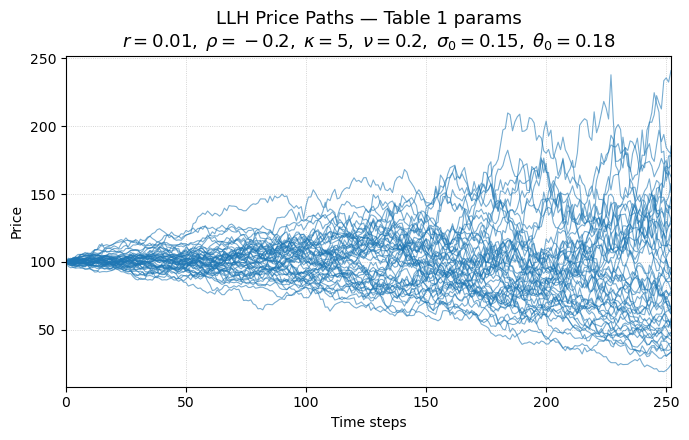

In [4]:
res_viz_t1 = model_t1.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=10000)
pm.plot(res_viz_t1['S'][:50].T,
        title="LLH Price Paths — Table 1 params\n"
              r"$r=0.01,\;\rho=-0.2,\;\kappa=5,\;\nu=0.2,\;\sigma_0=0.15,\;\theta_0=0.18$")

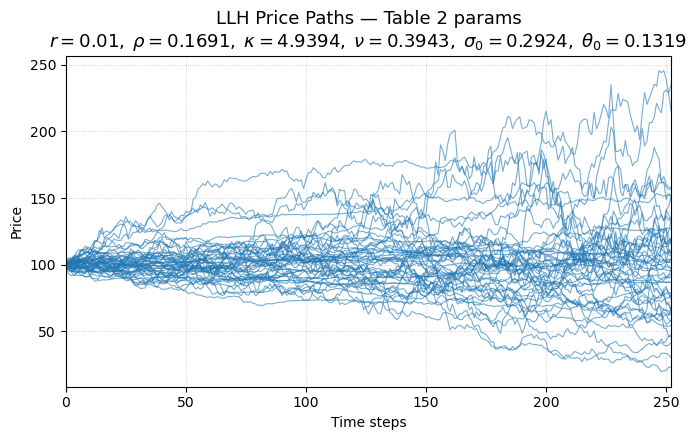

In [5]:
res_viz_t2 = model_t2.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=10000)
pm.plot(res_viz_t2['S'][:50].T,
        title="LLH Price Paths — Table 2 params\n"
              r"$r=0.01,\;\rho=0.1691,\;\kappa=4.9394,\;\nu=0.3943,\;\sigma_0=0.2924,\;\theta_0=0.1319$")

<a id="1month"></a>
## 4. American Put Pricing: 1-Month Horizon ($T = 1/12$ yr, 22 exercise dates)

Short-dated puts where the early exercise premium is small. Deep ITM puts
($S_0=85$, $K=100$) carry intrinsic value $\approx 15$, making early exercise
attractive. OTM puts ($S_0 \geq 110$) are nearly worthless.

### 4.1 Table 1 Parameters

In [6]:
%%time
df_t1_1m = american_put_comparison(
    model_t1, K=K, S0_grid=S0_GRID, moneyness_labels=MONEYNESS_LABELS,
    T=1/12, n_steps_mc=22,
    n_paths=N_PATHS, n_paths_llh=N_PATHS_LLH, llh_params=LLH_PARAMS
)

CPU times: user 37.6 s, sys: 32.2 s, total: 1min 9s
Wall time: 1min 8s


In [7]:
print("American Put Prices — Table 1 params, T = 1 month")
display(format_results_table(df_t1_1m))

American Put Prices — Table 1 params, T = 1 month


,S0,MC Put,MC Put SE,LSM Price,LSM SE,CV-LLH Price,CV-LLH SE,CV-LLH VR
Moneyness,,,,,,,,
Deep ITM,85,14.9059,0.0398,15.0000,0.0082,15.0000,0.0000,3250337.5
ITM,90,9.9225,0.0417,10.0000,0.0088,10.0000,0.0001,27620.8
ATM,100,1.8100,0.0272,1.8319,0.0261,1.8237,0.0000,476572.4
OTM,110,0.0515,0.0041,0.0542,0.0044,0.0652,0.0000,2506387.9
Deep OTM,115,0.0036,0.0010,0.0038,0.0010,0.0086,0.0000,19015256.3


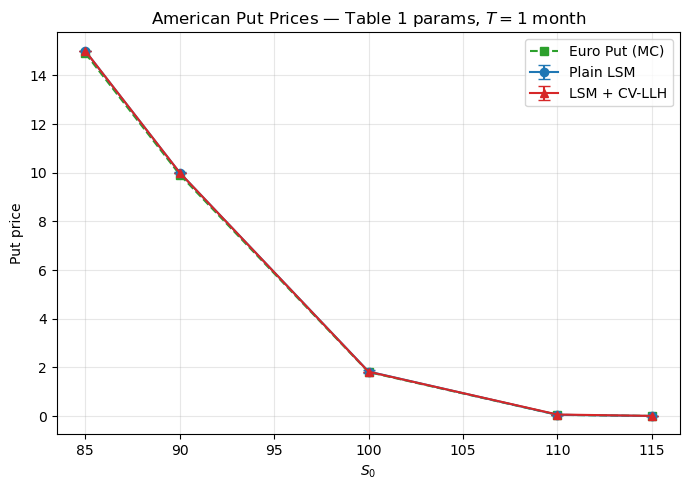

In [8]:
plot_american_put_prices(df_t1_1m, title='American Put Prices — Table 1 params, $T = 1$ month')

### 4.2 Table 2 Parameters

Table 2 has higher vol-of-vol ($\nu = 0.3943$) and positive correlation
($\rho = 0.1691$), which may affect control variate effectiveness differently.

In [9]:
# Path counts
N_PATHS       = 10_000   
N_PATHS_LLH   = 10_000 

In [10]:
%%time

df_t2_1m = american_put_comparison(
    model_t2, K=K, S0_grid=S0_GRID, moneyness_labels=MONEYNESS_LABELS,
    T=1/12, n_steps_mc=22,
    n_paths=N_PATHS, n_paths_llh=N_PATHS_LLH, llh_params=LLH_PARAMS
)

CPU times: user 36.6 s, sys: 13.7 s, total: 50.4 s
Wall time: 49.1 s


In [11]:
print("American Put Prices — Table 2 params, T = 1 month")
display(format_results_table(df_t2_1m))

American Put Prices — Table 2 params, T = 1 month


,S0,MC Put,MC Put SE,LSM Price,LSM SE,CV-LLH Price,CV-LLH SE,CV-LLH VR
Moneyness,,,,,,,,
Deep ITM,85,14.9840,0.0653,15.0344,0.0440,15.0557,0.0001,178175.0
ITM,90,10.2762,0.0637,10.2899,0.0503,10.3343,0.0001,301668.1
ATM,100,3.0666,0.0428,3.0822,0.0414,3.0675,0.0000,694045.9
OTM,110,0.4131,0.0154,0.4215,0.0153,0.4195,0.0000,1241512.9
Deep OTM,115,0.1120,0.0075,0.1167,0.0078,0.1254,0.0000,797251.5


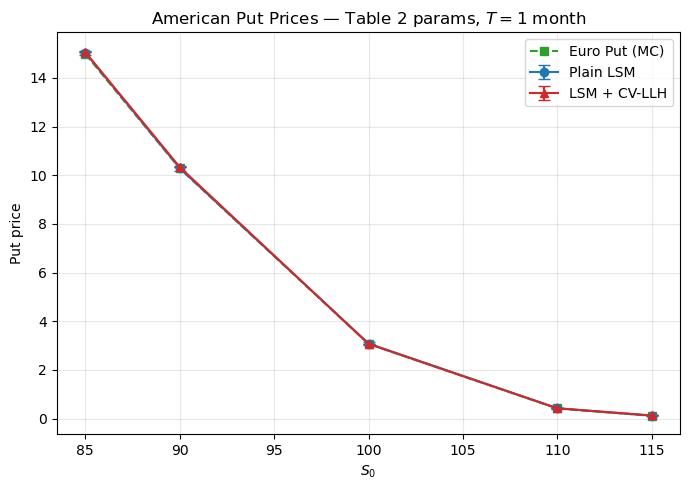

In [12]:
plot_american_put_prices(df_t2_1m, title='American Put Prices — Table 2 params, $T = 1$ month')

<a id="1year"></a>
## 5. American Put Pricing: 1-Year Horizon ($T = 1.0$ yr, 52 exercise dates)

The longer horizon gives more exercise opportunities, larger early exercise
premiums, and wider confidence intervals for plain LSM. We expect the control
variates to provide more pronounced variance reduction here.

In [13]:
# Path counts
N_PATHS       = 10_000   # plain LSM and CV-BS (fast)
N_PATHS_LLH   = 10_000    # CV-LLH (expensive: ODE solve per exercise date)


### 5.1 Table 1 Parameters

In [14]:
%%time
df_t1_1y = american_put_comparison(
    model_t1, K=K, S0_grid=S0_GRID, moneyness_labels=MONEYNESS_LABELS,
    T=1.0, n_steps_mc=52,
    n_paths=N_PATHS, n_paths_llh=N_PATHS_LLH, llh_params=LLH_PARAMS
)

CPU times: user 1min 25s, sys: 30 s, total: 1min 55s
Wall time: 1min 52s


In [15]:
print("American Put Prices — Table 1 params, T = 1 year")
display(format_results_table(df_t1_1y))

American Put Prices — Table 1 params, T = 1 year


,S0,MC Put,MC Put SE,LSM Price,LSM SE,CV-LLH Price,CV-LLH SE,CV-LLH VR
Moneyness,,,,,,,,
Deep ITM,85,26.5175,0.2435,26.8138,0.2315,27.0564,0.0003,472119.4
ITM,90,24.1039,0.2384,24.2899,0.2242,24.6362,0.0003,569333.1
ATM,100,19.9091,0.2259,20.0554,0.2168,20.4120,0.0002,773305.3
OTM,110,16.4436,0.2117,16.4791,0.2023,16.9128,0.0002,996177.2
Deep OTM,115,14.9551,0.2042,15.0622,0.1999,15.3994,0.0002,1146557.4


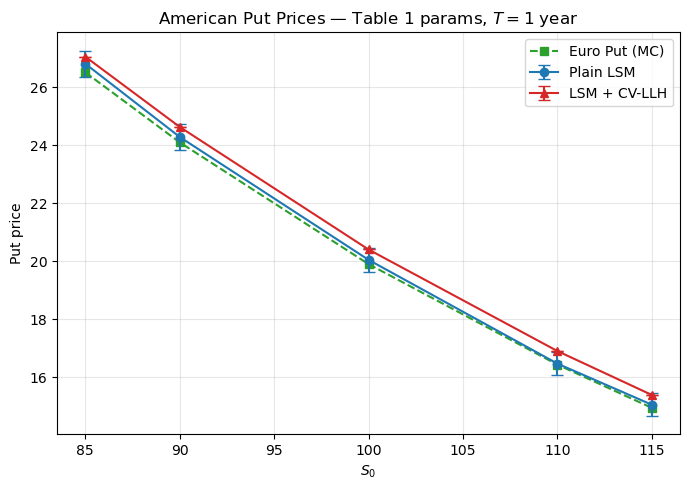

In [16]:
plot_american_put_prices(df_t1_1y, title='American Put Prices — Table 1 params, $T = 1$ year')

### 5.2 Table 2 Parameters

In [17]:
%%time
df_t2_1y = american_put_comparison(
    model_t2, K=K, S0_grid=S0_GRID, moneyness_labels=MONEYNESS_LABELS,
    T=1.0, n_steps_mc=52,
    n_paths=N_PATHS, n_paths_llh=N_PATHS_LLH, llh_params=LLH_PARAMS
)

CPU times: user 1min 36s, sys: 35.5 s, total: 2min 12s
Wall time: 2min 8s


In [18]:
print("American Put Prices — Table 2 params, T = 1 year")
display(format_results_table(df_t2_1y))

American Put Prices — Table 2 params, T = 1 year


,S0,MC Put,MC Put SE,LSM Price,LSM SE,CV-LLH Price,CV-LLH SE,CV-LLH VR
Moneyness,,,,,,,,
Deep ITM,85,20.7933,0.1867,20.9214,0.1769,20.8966,0.0008,44586.6
ITM,90,17.6897,0.1821,17.8468,0.1754,17.7975,0.0007,62516.7
ATM,100,12.6375,0.1685,12.6991,0.1639,12.7186,0.0005,116892.6
OTM,110,9.0036,0.1521,9.0709,0.1495,9.0798,0.0003,196378.1
Deep OTM,115,7.6353,0.1437,7.6924,0.1410,7.7153,0.0003,274295.5


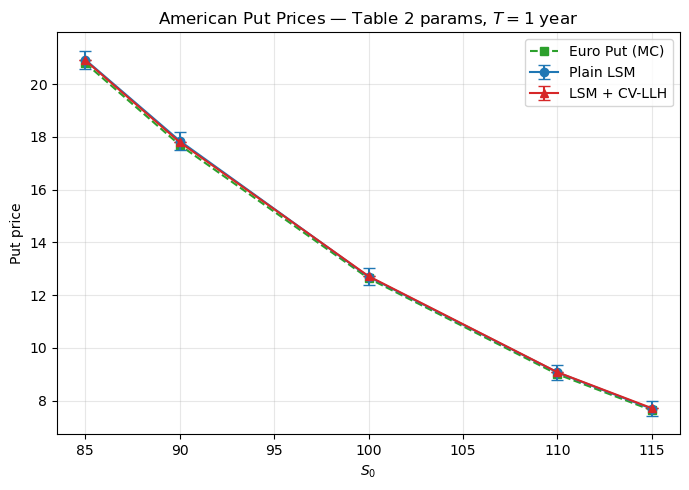

In [19]:
plot_american_put_prices(df_t2_1y, title='American Put Prices — Table 2 params, $T = 1$ year')

### 5.3 Black-Scholes Limit

We set all stochastic volatility parameters to zero ($\kappa = \nu = \lambda =
\eta = \rho = 0$), recovering geometric Brownian motion with constant volatility
$\sigma_0 = 0.2$ and $r = 0.05$ (the same BS parameters used in the European
pricing notebook). Under GBM the Black-Scholes European put is exact, so CV-BS
should act as a perfect control variate and deliver substantial variance
reduction.

Only Plain LSM and LSM + CV-BS are shown; CV-LLH reduces to CV-BS in this
limit. All European put prices are computed via the closed-form Black-Scholes
formula (`euro_method='bs'`).

In [20]:
# Black-Scholes limit (same parameters as european_pricing.ipynb §5.1)
model_bs = pm.ImprovedSteinStein(
    r=0.05, rho=0.0, kappa=0.0, nu=0.0,
    sigma0=0.2, theta0=0.0, lam=0.0, eta=0.0, seed=42
)

N_PATHS_BS = 50_000

In [21]:
%%time
df_bs_1y = american_put_comparison(
    model_bs, K=K, S0_grid=S0_GRID, moneyness_labels=MONEYNESS_LABELS,
    T=1.0, n_steps_mc=52,
    n_paths=N_PATHS_BS, include_llh=False
)

CPU times: user 6.11 s, sys: 458 ms, total: 6.57 s
Wall time: 5.87 s


In [22]:
print("American Put Prices — Black-Scholes limit, T = 1 year")
display(format_results_table(df_bs_1y))

American Put Prices — Black-Scholes limit, T = 1 year


,S0,MC Put,MC Put SE,LSM Price,LSM SE,CV-LLH Price,CV-LLH SE,CV-LLH VR
Moneyness,,,,,,,,
Deep ITM,85,13.3204,0.0542,15.3164,0.0290,15.2785,0.0017,273.5
ITM,90,10.2036,0.0497,11.5029,0.0345,11.4626,0.0018,362.3
ATM,100,5.5740,0.0388,6.0453,0.0315,6.0723,0.0013,563.8
OTM,110,2.7925,0.0278,2.9939,0.0244,2.9770,0.0009,799.2
Deep OTM,115,1.9221,0.0230,2.0423,0.0202,2.0303,0.0007,898.0


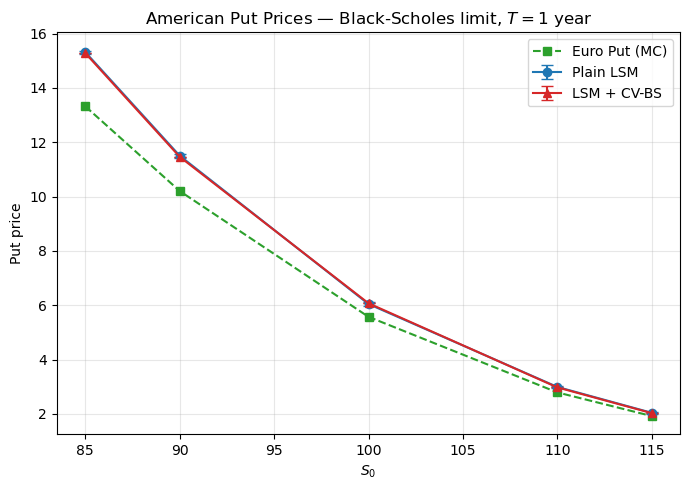

In [23]:
plot_american_put_prices(df_bs_1y,
    title='American Put Prices — Black-Scholes limit, $T = 1$ year',
    cv_method='bs')

<a id="eep"></a>
## 6. Early Exercise Premium

The early exercise premium (EEP) is the difference between the American and
European put prices: $\text{EEP} = P_{\text{Am}} - P_{\text{Eu}}$. It should
always be non-negative. The EEP is computed relative to the MC European put
price. The LLH analytical European put is included as a reference.

In [24]:
eep_results = {
    ('Table 1', '1-month'): df_t1_1m, ('Table 1', '1-year'): df_t1_1y,
    ('Table 2', '1-month'): df_t2_1m, ('Table 2', '1-year'): df_t2_1y,
}
models = {'Table 1': model_t1, 'Table 2': model_t2}

eep_df = build_eep_table(eep_results, models, K=K)
display(eep_df)

S0  Euro Put (MC)  Euro Put (LLH)  Amer Put (LSM)  \
Params  Horizon Moneyness                                                       
Table 1 1-month Deep ITM    85        14.9059         14.9173         15.0000   
                ITM         90         9.9225          9.9371         10.0000   
                ATM        100         1.8100          1.8205          1.8319   
                OTM        110         0.0515          0.0652          0.0542   
                Deep OTM   115         0.0036          0.0086          0.0038   
        1-year  Deep ITM    85        26.5175         27.0243         26.8138   
                ITM         90        24.1039         24.6095         24.2899   
                ATM        100        19.9091         20.3934         20.0554   
                OTM        110        16.4436         16.8995         16.4791   
                Deep OTM   115        14.9551         15.3882         15.0622   
Table 2 1-month Deep ITM    85        14.9840         15.0158         15.0344   
                ITM         90        10.2762         10.3116         10.2899   
                ATM        100         3.0666          3.0632          3.0822   
                OTM        110         0.4131          0.4192          0.4215   
                Deep OTM   115         0.1120          0.1253          0.1167   
        1-year  Deep ITM    85        20.7933         20.8099         20.9214   
                ITM         90        17.6897         17.7332         17.8468   
                ATM        100        12.6375         12.6836         12.6991   
                OTM        110         9.0036          9.0607          9.0709   
                Deep OTM   115         7.6353          7.7015          7.6924   

                           EEP (LSM)  EEP % (LSM)  Amer Put (CV-LLH)  \
Params  Horizon Moneyness                                              
Table 1 1-month Deep ITM      0.0941         0.63            15.0000   
                ITM           0.0775         0.78            10.0000   
                ATM           0.0220         1.21             1.8237   
                OTM           0.0027         5.25             0.0652   
                Deep OTM      0.0002          NaN             0.0086   
        1-year  Deep ITM      0.2963         1.12            27.0564   
                ITM           0.1861         0.77            24.6362   
                ATM           0.1463         0.73            20.4120   
                OTM           0.0355         0.22            16.9128   
                Deep OTM      0.1071         0.72            15.3994   
Table 2 1-month Deep ITM      0.0503         0.34            15.0557   
                ITM           0.0137         0.13            10.3343   
                ATM           0.0155         0.51             3.0675   
                OTM           0.0085         2.05             0.4195   
                Deep OTM      0.0046         4.14             0.1254   
        1-year  Deep ITM      0.1281         0.62            20.8966   
                ITM           0.1570         0.89            17.7975   
                ATM           0.0617         0.49            12.7186   
                OTM           0.0673         0.75             9.0798   
                Deep OTM      0.0571         0.75             7.7153   

                           EEP (CV-LLH)  EEP % (CV-LLH)  
Params  Horizon Moneyness                                
Table 1 1-month Deep ITM         0.0941            0.63  
                ITM              0.0775            0.78  
                ATM              0.0138            0.76  
                OTM              0.0137           26.58  
                Deep OTM         0.0050             NaN  
        1-year  Deep ITM         0.5389            2.03  
                ITM              0.5323            2.21  
                ATM              0.5029            2.53  
                OTM              0.4692            2.85  
                Deep O

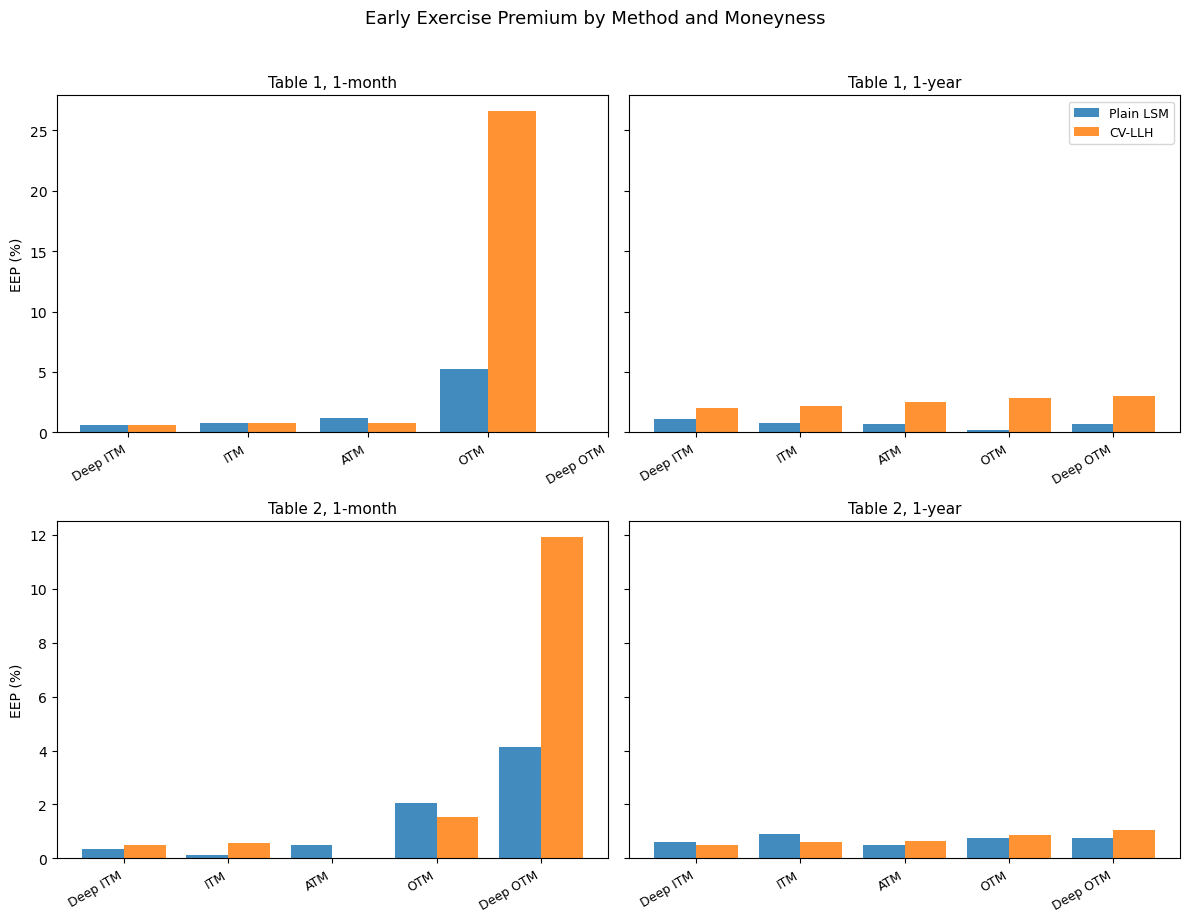

In [25]:
plot_eep_table(eep_df)

**Observations:**
- The EEP should be non-negative ($P_{\text{Am}} \geq P_{\text{Eu}}$).
- Deep ITM puts carry the largest EEP because early exercise captures the time
  value of money on the intrinsic value.
- The 1-year horizon produces a larger EEP than 1-month, as there is more time
  during which early exercise can be optimal.
- OTM puts have near-zero EEP since they are unlikely to be exercised early.

<a id="vr-analysis"></a>
## 7. Variance Reduction Analysis

We consolidate the variance reduction ratios from Sections 4-5 into a single
summary view. A VR ratio greater than 1 indicates that the control variate
reduced the estimator variance relative to plain LSM (on matched path counts).

In [27]:
vr_df = build_vr_summary({
    'T1, 1m': df_t1_1m, 'T1, 1y': df_t1_1y,
    'T2, 1m': df_t2_1m, 'T2, 1y': df_t2_1y,
})

print("Variance Reduction Ratios (VR > 1 means CV helped)")
display(vr_df.pivot_table(index='Moneyness', columns='Setting',
                           values=['CV-LLH VR']).round(1))

Variance Reduction Ratios (VR > 1 means CV helped)


CV-LLH VR                                
Setting        T1, 1m     T1, 1y     T2, 1m    T2, 1y
Moneyness                                            
ATM          476572.4   773305.3   694045.9  116892.6
Deep ITM    3250337.5   472119.4   178175.0   44586.6
Deep OTM   19015256.3  1146557.4   797251.5  274295.5
ITM           27620.8   569333.1   301668.1   62516.7
OTM         2506387.9   996177.2  1241512.9  196378.1

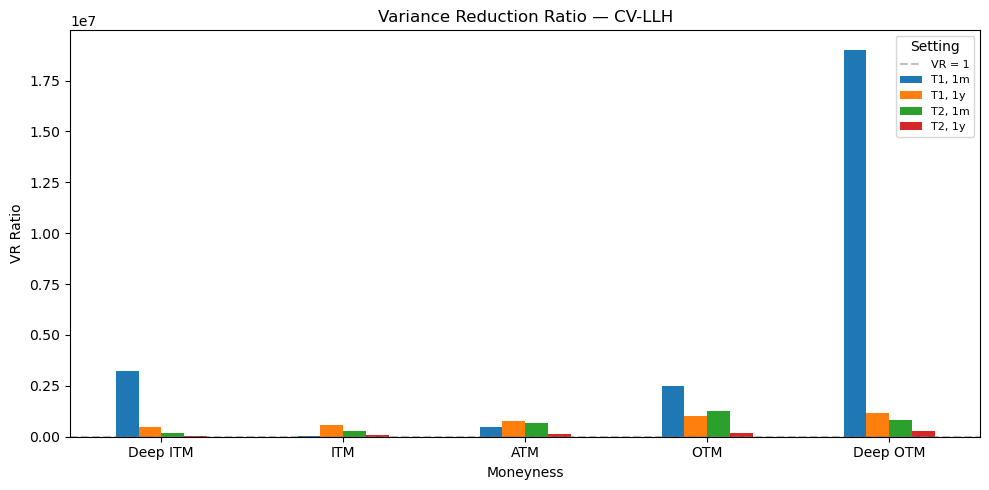

In [28]:
plot_vr_bars(vr_df, MONEYNESS_LABELS)

<a id="timing"></a>
## 8. Timing Comparison

We time the three methods on a single ITM configuration ($S_0=90$, $K=100$)
under Table 2 parameters for both horizons, quantifying the runtime-accuracy tradeoff.

In [29]:
timing_df = build_timing_table(
    model_t2, K=100.0, S0=90.0, horizons=HORIZONS,
    n_paths=N_PATHS, n_paths_llh=N_PATHS_LLH, llh_params=LLH_PARAMS
)
display(timing_df)

,Plain LSM (s),Plain LSM SE,CV-LLH (s),CV-LLH SE
Horizon,,,,
1-month,0.073,0.0503,17.911,0.0001
1-year,0.132,0.1754,29.666,0.0007


**Observations:**
- CV-BS adds minimal overhead over plain LSM while providing moderate variance reduction.
- CV-LLH is orders of magnitude slower due to the ODE solve at each exercise
  date for each unique $\tau$. Whether the variance reduction justifies the
  cost depends on the accuracy requirements of the application.